# Figure 1. 복소평면에서 zeta(s)의 zeros 분포

- lec-001: Intro and the Basel Problem
- docs/contents/lec-001/images/fig-001-001.png

In [1]:
import os
import sys

ROOT_DIR = os.path.normpath(os.path.join(os.getcwd(), "..", "..", ".."))
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

In [4]:
# 설정
plt.rcParams.update({
    "text.usetex"       : False,   # True로 변경 시 LaTeX 렌더링 (LaTeX 설치 필요)
    "font.family"       : "serif",
    "font.size"         : 11,
    "axes.titlesize"    : 12,
})

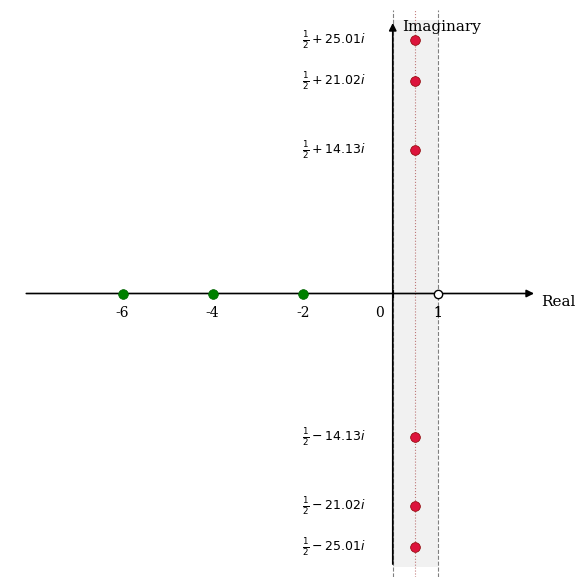

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
 
# 축 설정
ax.set_xlim(-8.5, 3.5)
ax.set_ylim(-28, 28)
# ax.set_aspect("equal")  # 제거 → 가로:세로 비율 자유
ax.axis("off")
 
# 복소평면 축 그리기 (화살표)
# Real 축
ax.annotate("", xy=(3.2, 0), xytext=(-8.2, 0),
            arrowprops=dict(arrowstyle="-|>", color="black", lw=1.2))
# Imaginary 축
ax.annotate("", xy=(0, 27), xytext=(0, -27),
            arrowprops=dict(arrowstyle="-|>", color="black", lw=1.2))
 
# 축 레이블
ax.text(3.3, -1.2, "Real",      fontsize=11, ha="left")
ax.text(0.2,  27,  "Imaginary", fontsize=11, ha="left", va="top")
 
# 눈금 및 레이블 (Real 축)
real_ticks = [-6, -4, -2, 0, 1]
for x in real_ticks:
    ax.plot([x, x], [-0.3, 0.3], color="black", lw=0.8)
    if x != 0:
        ax.text(x, -1.2, str(x), ha="center", va="top", fontsize=10)
    else:
        ax.text(x - 0.3, -1.2, "0", ha="center", va="top", fontsize=10)
 
# 1 레이블
ax.text(1, -1.2, "1", ha="center", va="top", fontsize=10)
 
# Critical strip 음영 (0 < Re(s) < 1)
strip = patches.Rectangle(
    (0, -27), 1, 54,
    linewidth=0, facecolor="lightgray", alpha=0.3, zorder=0
)
ax.add_patch(strip)
 
# Critical strip 경계선 (점선)
ax.axvline(x=0, color="gray", lw=0.8, linestyle="--", zorder=1)
ax.axvline(x=1, color="gray", lw=0.8, linestyle="--", zorder=1)
 
# Critical line (Re(s) = 1/2) 점선
ax.axvline(x=0.5, color="darkred", lw=0.8, linestyle=":", alpha=0.5, zorder=1)
 
# Trivial zeros (녹색, 음의 짝수 정수)
trivial_zeros = [-2, -4, -6]
for x in trivial_zeros:
    ax.plot(x, 0, "o",
            color="green", markersize=7,
            markeredgecolor="darkgreen", markeredgewidth=0.5,
            zorder=3)
 
# Nontrivial zeros (적색, Re(s) = 1/2)
nontrivial_im = [14.13, 21.02, 25.01]
for im in nontrivial_im:
    for sign in [1, -1]:
        ax.plot(0.5, sign * im, "o",
                color="crimson", markersize=7,
                markeredgecolor="darkred", markeredgewidth=0.5,
                zorder=3)
 
# Nontrivial zeros 레이블
label_x = -0.6   # 레이블 x 위치 (왼쪽)
for im in nontrivial_im:
    # 양수 방향
    ax.text(label_x, im,
            r"$\frac{1}{2} + " + f"{im}" + r"i$",
            ha="right", va="center", fontsize=9, color="black")
    # 음수 방향
    ax.text(label_x, -im,
            r"$\frac{1}{2} - " + f"{im}" + r"i$",
            ha="right", va="center", fontsize=9, color="black")
 
# Pole at s=1 (작은 원)
ax.plot(1, 0, "o",
        color="white", markersize=6,
        markeredgecolor="black", markeredgewidth=1.0,
        zorder=3)

plt.tight_layout()
plt.show()